# 06 — Neural Networks

Neural Networks are computational models composed of interconnected
layers of artificial neurons. They form the foundation of modern
Deep Learning systems.

In this notebook, we will study neural networks from both:

- a mathematical perspective
- an algorithmic perspective
- a practical implementation perspective

We will derive forward propagation, loss computation,
backpropagation, and gradient descent, and then implement a
neural network from scratch using NumPy.

Finally, we will use scikit-learn and PyTorch to build practical
neural-network models.

---

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain how an artificial neuron works.
2. Understand the perceptron algorithm.
3. Explain why a single perceptron cannot solve nonlinear problems.
4. Describe the architecture of a multilayer neural network.
5. Derive forward propagation mathematically.
6. Explain activation functions and their importance.
7. Understand loss functions for different tasks.
8. Derive the basic backpropagation algorithm.
9. Explain the role of the chain rule.
10. Implement a neural network from scratch using NumPy.
11. Train neural networks using gradient descent.
12. Understand initialization and gradient problems.
13. Explain regularization techniques such as dropout and early stopping.
14. Build neural networks using scikit-learn and PyTorch.
15. Diagnose common neural-network training problems.

## 1. What Is a Neural Network?

A neural network is a parameterized function that transforms an input
into an output through a sequence of computational layers.

A simple neural network can be represented as:

$$
\mathbf{x}
\rightarrow
\text{Hidden Layer}
\rightarrow
\text{Output Layer}
\rightarrow
\hat{\mathbf{y}}
$$

Each layer performs two main operations:

1. A linear transformation
2. A nonlinear activation

For a layer:

$$
\mathbf{z} = W\mathbf{x} + \mathbf{b}
$$

followed by:

$$
\mathbf{a} = \sigma(\mathbf{z})
$$

where:

- $W$ = weight matrix
- $\mathbf{b}$ = bias vector
- $\mathbf{x}$ = input
- $\mathbf{z}$ = pre-activation
- $\sigma$ = activation function
- $\mathbf{a}$ = activation

A neural network learns the parameters:

$$
W_1, W_2, \ldots, W_L
$$

and

$$
b_1, b_2, \ldots, b_L
$$

from training data.

## 2. Artificial Neuron

The basic computational unit of a neural network is an artificial neuron.

Given inputs:

$$
x_1,x_2,\ldots,x_n
$$

the neuron computes:

$$
z = \sum_{i=1}^{n} w_i x_i + b
$$

or equivalently:

$$
z = \mathbf{w}^T\mathbf{x}+b
$$

The result is passed through an activation function:

$$
a = \sigma(z)
$$

Therefore:

$$
\boxed{
a = \sigma(\mathbf{w}^T\mathbf{x}+b)
}
$$

The weights determine the importance of the inputs, while the bias
controls the position of the decision boundary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2.0, 3.0])

w = np.array([0.5, -0.2])
b = 0.4

z = np.dot(w, x) + b

print("Pre-activation:", z)

Pre-activation: 0.8


## 3. The Perceptron

The perceptron is one of the simplest neural-network models.

It computes:

$$
z = \mathbf{w}^T\mathbf{x}+b
$$

and applies a step function:

$$
\hat{y} =
\begin{cases}
1 & z \geq 0\\
0 & z < 0
\end{cases}
$$

The perceptron therefore produces a binary prediction.

---

## Perceptron Decision Boundary

The decision boundary occurs when:

$$
\mathbf{w}^T\mathbf{x}+b=0
$$

For two features:

$$
w_1x_1+w_2x_2+b=0
$$

which can be rewritten as:

$$
x_2 =
-\frac{w_1}{w_2}x_1
-\frac{b}{w_2}
$$

Therefore, a perceptron can only learn a **linear decision boundary**.

##  Visualize a Perceptron

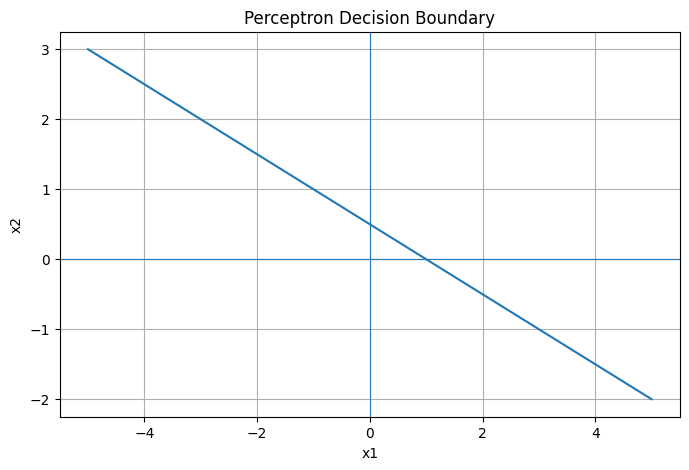

In [2]:
x1 = np.linspace(-5, 5, 100)

w1 = 1
w2 = 2
b = -1

x2 = -(w1 * x1 + b) / w2

plt.figure(figsize=(8, 5))
plt.plot(x1, x2)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary")
plt.grid(True)
plt.show()

# Why One Neuron Is Not Enough
## 4. Limitation of a Single Perceptron

A single perceptron can solve linearly separable problems.

For example:

- AND
- OR

But it cannot solve problems where the classes cannot be separated
by a single straight line.

The classic example is XOR.

---

## XOR

The XOR truth table is:

| $x_1$ | $x_2$ | $y$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

No single linear decision boundary can separate these two classes.

Therefore:

$$
\boxed{
\text{Single perceptron} \neq \text{universal nonlinear classifier}
}
$$

This motivates the use of multiple neurons and multiple layers.

## 5. Multilayer Perceptron (MLP)

A multilayer perceptron contains:

- Input layer
- One or more hidden layers
- Output layer

For example:

$$
\mathbf{x}
\rightarrow
\mathbf{a}^{(1)}
\rightarrow
\mathbf{a}^{(2)}
\rightarrow
\hat{\mathbf{y}}
$$

A network with one hidden layer can be written as:

$$
\mathbf{z}^{(1)}
=
W^{(1)}\mathbf{x}+\mathbf{b}^{(1)}
$$

$$
\mathbf{a}^{(1)}
=
\sigma(\mathbf{z}^{(1)})
$$

Then:

$$
\mathbf{z}^{(2)}
=
W^{(2)}\mathbf{a}^{(1)}
+\mathbf{b}^{(2)}
$$

and:

$$
\hat{\mathbf{y}}
=
g(\mathbf{z}^{(2)})
$$

where $g$ is the output activation function.

## Neural Network Architecture Visualization

In [3]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(8, 4),
    max_iter=1000,
    random_state=42
)

print(model)

MLPClassifier(hidden_layer_sizes=(8, 4), max_iter=1000, random_state=42)


## 6. Forward Propagation

Forward propagation is the process of passing an input through the
network to produce a prediction.

Consider a network with one hidden layer.

### Hidden Layer

$$
\mathbf{z}^{(1)}
=
W^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}
$$

Apply activation:

$$
\mathbf{a}^{(1)}
=
\sigma(\mathbf{z}^{(1)})
$$

### Output Layer

$$
\mathbf{z}^{(2)}
=
W^{(2)}\mathbf{a}^{(1)}
+
\mathbf{b}^{(2)}
$$

Then:

$$
\hat{\mathbf{y}}
=
g(\mathbf{z}^{(2)})
$$

Therefore the entire network represents a composition of functions:

$$
f(\mathbf{x})
=
g
\left(
W^{(2)}
\sigma
\left(
W^{(1)}\mathbf{x}
+
\mathbf{b}^{(1)}
\right)
+
\mathbf{b}^{(2)}
\right)
$$

This composition of transformations is what gives neural networks
their expressive power.

## 7. Activation Functions

Activation functions introduce nonlinearity into neural networks.

Without nonlinear activation functions, stacking multiple linear
layers would still produce a linear function.

For example:

$$
f(x)=W_2(W_1x+b_1)+b_2
$$

can be rewritten as:

$$
f(x)=W'x+b'
$$

Therefore, without nonlinear activation functions:

$$
\boxed{
\text{Multiple linear layers} = \text{one linear transformation}
}
$$

Activation functions prevent this collapse.

### Sigmoid

$$
\sigma(x)
=
\frac{1}{1+e^{-x}}
$$

Range:

$$
0 < \sigma(x) < 1
$$

Derivative:

$$
\sigma'(x)
=
\sigma(x)(1-\sigma(x))
$$

Sigmoid is commonly used at the output layer for binary
classification.

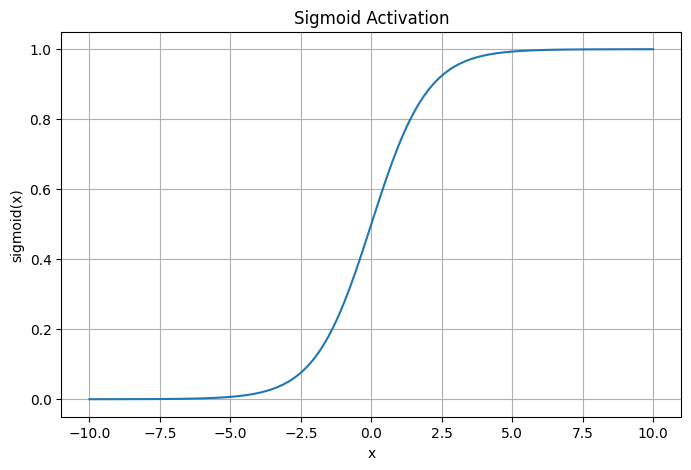

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 200)

plt.figure(figsize=(8, 5))
plt.plot(x, sigmoid(x))
plt.title("Sigmoid Activation")
plt.xlabel("x")
plt.ylabel("sigmoid(x)")
plt.grid(True)
plt.show()

## Tanh

$$
\tanh(x)
=
\frac{e^x-e^{-x}}{e^x+e^{-x}}
$$

Range:

$$
-1 < \tanh(x) < 1
$$

Derivative:

$$
\frac{d}{dx}\tanh(x)
=
1-\tanh^2(x)
$$

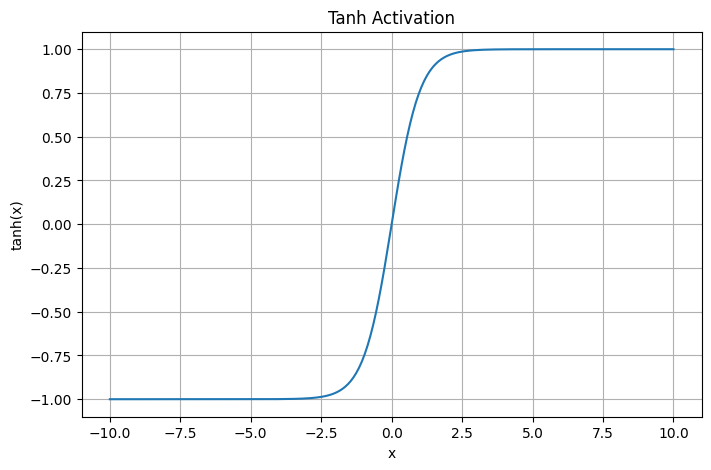

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(x, np.tanh(x))
plt.title("Tanh Activation")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid(True)
plt.show()

## ReLU

The Rectified Linear Unit is:

$$
\operatorname{ReLU}(x)
=
\max(0,x)
$$

Derivative:

$$
\operatorname{ReLU}'(x)
=
\begin{cases}
0 & x<0\\
1 & x>0
\end{cases}
$$

ReLU became extremely important because it is computationally simple
and generally avoids some of the optimization difficulties associated
with sigmoid and tanh in deep networks.

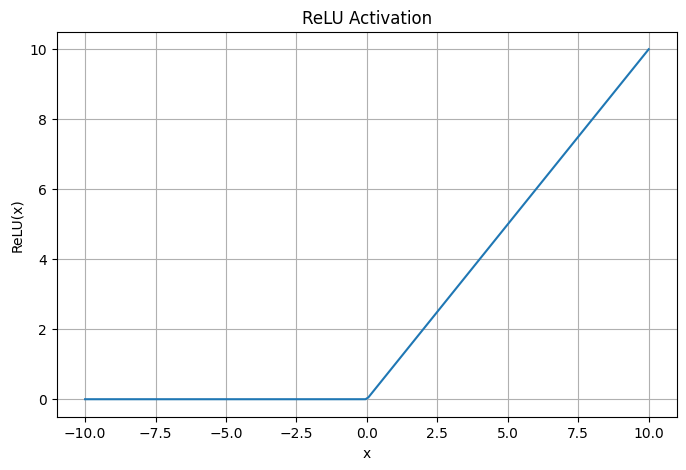

In [6]:
def relu(x):
    return np.maximum(0, x)

plt.figure(figsize=(8, 5))
plt.plot(x, relu(x))
plt.title("ReLU Activation")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.grid(True)
plt.show()

## Compare Activation Functions

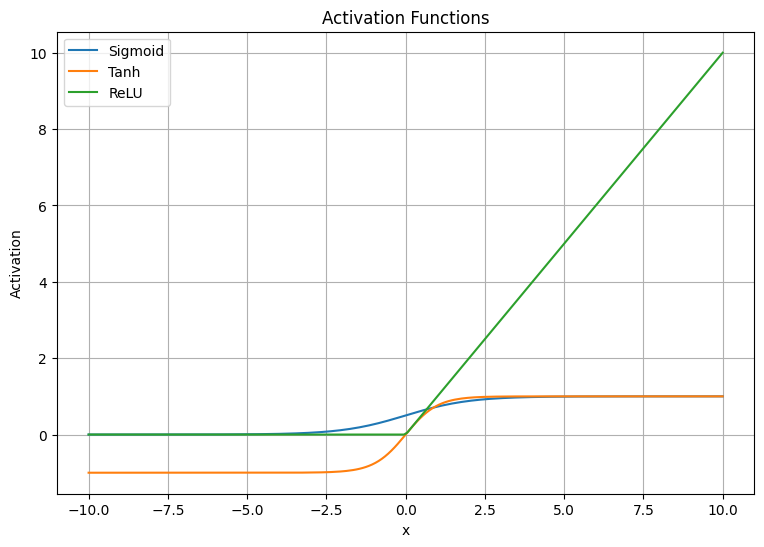

In [7]:
plt.figure(figsize=(9, 6))

plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, np.tanh(x), label="Tanh")
plt.plot(x, relu(x), label="ReLU")

plt.xlabel("x")
plt.ylabel("Activation")
plt.title("Activation Functions")
plt.legend()
plt.grid(True)
plt.show()

## Softmax

For multiclass classification, the output layer often uses softmax.

For logits:

$$
z_1,z_2,\ldots,z_K
$$

softmax computes:

$$
P(y=k|\mathbf{x})
=
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
$$

Therefore:

$$
\sum_{k=1}^{K}P(y=k|\mathbf{x})=1
$$

The output can therefore be interpreted as a probability distribution
over the classes.

In [8]:
def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z)

logits = np.array([2.0, 1.0, 0.1])

print(softmax(logits))
print("Sum:", softmax(logits).sum())

[0.65900114 0.24243297 0.09856589]
Sum: 1.0


## 8. Loss Functions

The network needs a way to measure how wrong its prediction is.

This is the purpose of the loss function.

---

### Mean Squared Error

For regression:

$$
L
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

---

### Binary Cross-Entropy

For binary classification:

$$
L
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

---

### Categorical Cross-Entropy

For multiclass classification:

$$
L
=
-\sum_{k=1}^{K}
y_k\log(\hat{y}_k)
$$

where $y_k$ is usually represented using one-hot encoding.

## 9. Computational Graph

A neural network can be represented as a computational graph.

For a simple neuron:

$$
x
\rightarrow
wx
\rightarrow
wx+b
\rightarrow
\sigma(wx+b)
\rightarrow
L
$$

This representation allows us to determine how the loss changes with
respect to each parameter.

The key mathematical tool is the **chain rule**.

## 10. Backpropagation

Backpropagation computes gradients of the loss with respect to the
network parameters.

The objective is to calculate:

$$
\frac{\partial L}{\partial W}
$$

and

$$
\frac{\partial L}{\partial b}
$$

for every layer.

The chain rule allows us to decompose complicated derivatives.

For:

$$
L=L(z)
$$

and:

$$
z=wx+b
$$

we obtain:

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial z}
\frac{\partial z}{\partial w}
$$

Since:

$$
\frac{\partial z}{\partial w}=x
$$

we get:

$$
\boxed{
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial z}x
}
$$

Similarly:

$$
\boxed{
\frac{\partial L}{\partial b}
=
\frac{\partial L}{\partial z}
}
$$

Backpropagation applies this idea repeatedly through all layers.

## 11. Gradient Descent

Once gradients have been calculated, the parameters are updated.

For a parameter $\theta$:

$$
\theta_{\text{new}}
=
\theta_{\text{old}}
-
\eta
\frac{\partial L}{\partial\theta}
$$

where:

- $\eta$ = learning rate
- $\frac{\partial L}{\partial\theta}$ = gradient

The negative sign moves the parameters in the direction that
decreases the loss.

The basic training loop is therefore:

1. Initialize parameters
2. Perform forward propagation
3. Calculate loss
4. Perform backpropagation
5. Calculate gradients
6. Update parameters
7. Repeat

## 12. Training Terminology

### Epoch

One complete pass through the training dataset.

### Batch

A subset of the training dataset used for one parameter update.

### Iteration

One optimization step using one batch.

If:

$$
N = 10,000
$$

and:

$$
B = 100
$$

then approximately:

$$
\frac{10,000}{100}=100
$$

iterations occur per epoch.

---

### Batch Gradient Descent

Uses the entire dataset for one update.

### Stochastic Gradient Descent

Uses one training example per update.

### Mini-Batch Gradient Descent

Uses a small subset of examples per update.

Modern neural-network training generally uses mini-batches.

# 13. Neural Network From Scratch

We will implement a small neural network using only NumPy.

Architecture:

$$
2
\rightarrow
4
\rightarrow
1
$$

That means:

- 2 input features
- 4 hidden neurons
- 1 output neuron

We will train it on the XOR problem.

This implementation will explicitly perform:

- initialization
- forward propagation
- loss computation
- backpropagation
- gradient descent

In [9]:
import numpy as np

np.random.seed(42)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print(X)
print(y)

[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
[[0.]
 [1.]
 [1.]
 [0.]]


## Initialize Parameters

In [10]:
input_size = 2
hidden_size = 4
output_size = 1

W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (2, 4)
b1 shape: (1, 4)
W2 shape: (4, 1)
b2 shape: (1, 1)


## Forward Pass

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = np.tanh(z1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    return z1, a1, z2, a2

## Binary Cross-Entropy

In [12]:
def binary_cross_entropy(y, y_pred):
    eps = 1e-8

    y_pred = np.clip(y_pred, eps, 1 - eps)

    return -np.mean(
        y * np.log(y_pred)
        + (1 - y) * np.log(1 - y_pred)
    )

## Backpropagation Derivation

For sigmoid output with binary cross-entropy loss:

$$
\delta^{(2)}
=
\hat{y}-y
$$

The gradient of the second-layer weights is:

$$
\frac{\partial L}{\partial W^{(2)}}
=
(a^{(1)})^T\delta^{(2)}
$$

The gradient of the second-layer bias is:

$$
\frac{\partial L}{\partial b^{(2)}}
=
\sum \delta^{(2)}
$$

The hidden-layer error is:

$$
\delta^{(1)}
=
\left(
\delta^{(2)}
(W^{(2)})^T
\right)
\odot
(1-(a^{(1)})^2)
$$

because we use tanh.

Then:

$$
\frac{\partial L}{\partial W^{(1)}}
=
X^T\delta^{(1)}
$$

In [13]:
def backward(X, y, z1, a1, z2, a2, W2):
    m = X.shape[0]

    dz2 = a2 - y

    dW2 = (a1.T @ dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m

    dz1 = (dz2 @ W2.T) * (1 - a1**2)

    dW1 = (X.T @ dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

## Training Loop

In [14]:
learning_rate = 0.5
epochs = 10000

loss_history = []

for epoch in range(epochs):

    # Forward propagation
    z1, a1, z2, a2 = forward(
        X, W1, b1, W2, b2
    )

    # Loss
    loss = binary_cross_entropy(y, a2)
    loss_history.append(loss)

    # Backpropagation
    dW1, db1, dW2, db2 = backward(
        X, y, z1, a1, z2, a2, W2
    )

    # Parameter updates
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 0.714539
Epoch 1000, Loss: 0.006274
Epoch 2000, Loss: 0.002704
Epoch 3000, Loss: 0.001718
Epoch 4000, Loss: 0.001258
Epoch 5000, Loss: 0.000992
Epoch 6000, Loss: 0.000819
Epoch 7000, Loss: 0.000697
Epoch 8000, Loss: 0.000607
Epoch 9000, Loss: 0.000537


## Plot Training Loss

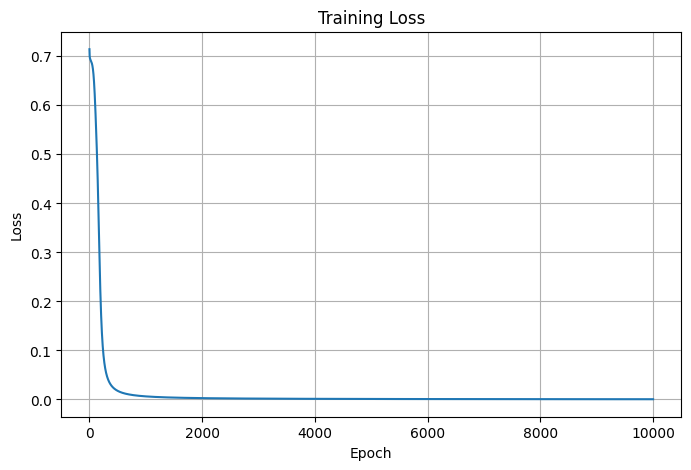

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

plt.show()

## Test XOR

In [16]:
_, _, _, predictions = forward(
    X, W1, b1, W2, b2
)

print("Probabilities:")
print(predictions)

print("\nPredicted classes:")
print((predictions >= 0.5).astype(int))

print("\nTrue labels:")
print(y.astype(int))

Probabilities:
[[3.50594783e-05]
 [9.99461389e-01]
 [9.99452529e-01]
 [8.04765608e-04]]

Predicted classes:
[[0]
 [1]
 [1]
 [0]]

True labels:
[[0]
 [1]
 [1]
 [0]]


This is an important milestone because we've just demonstrated that a multilayer neural network can learn a nonlinear decision function that a single perceptron cannot.

## Decision Boundary

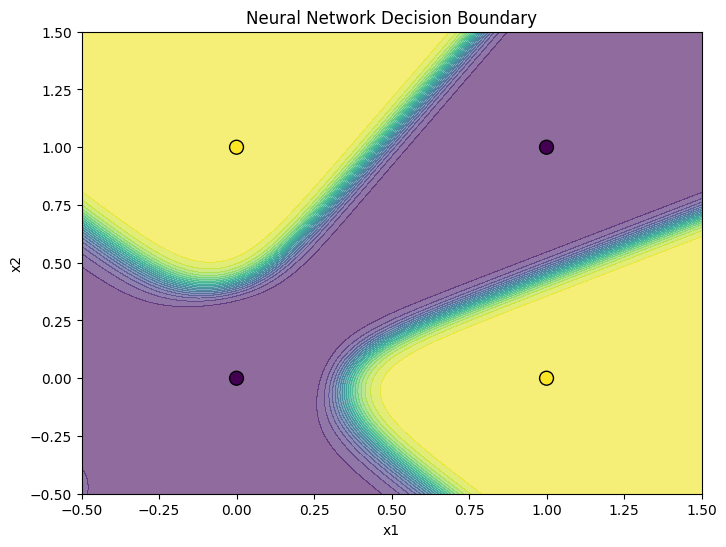

In [17]:
xx, yy = np.meshgrid(
    np.linspace(-0.5, 1.5, 300),
    np.linspace(-0.5, 1.5, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

_, _, _, probs = forward(
    grid, W1, b1, W2, b2
)

probs = probs.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    probs,
    levels=20,
    alpha=0.6
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y.ravel(),
    s=100,
    edgecolor="black"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Neural Network Decision Boundary")
plt.show()

# 14. Weight Initialization

The initial values of the weights can strongly affect training.

Bad initialization can cause:

- vanishing gradients
- exploding gradients
- slow convergence
- neurons learning similar features

---

## Zero Initialization

If all weights are initialized to zero, neurons in the same layer
can receive identical gradients.

This creates a symmetry problem.

Therefore, neural-network weights should generally not be initialized
to zero.

---

## Xavier Initialization

For certain activation functions:

$$
W \sim
\mathcal{N}
\left(
0,
\frac{1}{n_{\text{in}}}
\right)
$$

or related uniform/normal variants.

---

## He Initialization

For ReLU-based networks:

$$
W \sim
\mathcal{N}
\left(
0,
\frac{2}{n_{\text{in}}}
\right)
$$

He initialization is particularly useful for ReLU networks.

# 15. Vanishing and Exploding Gradients

During backpropagation, gradients are repeatedly multiplied through
the layers of the network.

If these factors are consistently smaller than 1:

$$
\prod_{i=1}^{L} g_i \rightarrow 0
$$

the gradient can become extremely small.

This is the **vanishing-gradient problem**.

If the factors are consistently larger than 1:

$$
\prod_{i=1}^{L} g_i \rightarrow \infty
$$

the gradient can become extremely large.

This is the **exploding-gradient problem**.

Important techniques for controlling these problems include:

- appropriate initialization
- ReLU-family activations
- normalization
- residual connections
- gradient clipping
- careful architecture design

# 16. Learning Rate

The learning rate controls the size of parameter updates.

$$
\theta_{t+1}
=
\theta_t
-
\eta\nabla_\theta L
$$

If $\eta$ is too small:

- training becomes slow

If $\eta$ is too large:

- optimization can become unstable
- loss may oscillate or diverge

Therefore learning-rate selection is one of the most important
practical aspects of neural-network training.

# 17. Neural Network Capacity

A network's capacity describes how complex a function it can represent.

Capacity can increase through:

- more neurons
- more layers
- more parameters

However, increasing capacity can also increase overfitting.

A very small network may:

$$
\text{Underfit}
$$

A very large network may:

$$
\text{Overfit}
$$

Therefore model architecture must balance expressive power and
generalization.

# 18. Regularization

Neural networks can contain millions or even billions of parameters.

Without appropriate regularization, they may memorize the training
data rather than learn patterns that generalize.

Common techniques include:

### L2 Regularization

$$
L_{\text{total}}
=
L_{\text{data}}
+
\lambda
\sum_j w_j^2
$$

### Dropout

Randomly sets a fraction of activations to zero during training.

### Early Stopping

Stops training when validation performance stops improving.

### Data Augmentation

Creates additional training examples through transformations of
existing data.

# 19. Batch Normalization

Batch normalization normalizes intermediate activations.

For a batch:

$$
\mu_B
=
\frac{1}{m}
\sum_{i=1}^{m}x_i
$$

and:

$$
\sigma_B^2
=
\frac{1}{m}
\sum_{i=1}^{m}
(x_i-\mu_B)^2
$$

Then:

$$
\hat{x}
=
\frac{x-\mu_B}
{\sqrt{\sigma_B^2+\epsilon}}
$$

followed by learnable parameters:

$$
y=\gamma\hat{x}+\beta
$$

Batch normalization can improve optimization and make training less
sensitive to initialization and learning-rate choices.

## scikit-learn Neural Network

In [18]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

X, y = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train MLP

In [19]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.985

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.98      0.99      0.99       100

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



## Training Curve

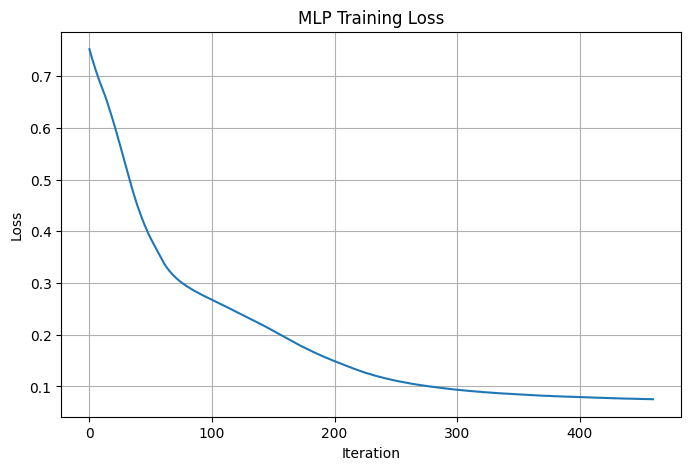

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(mlp.loss_curve_)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.grid(True)

plt.show()

## Decision Boundary for MLP

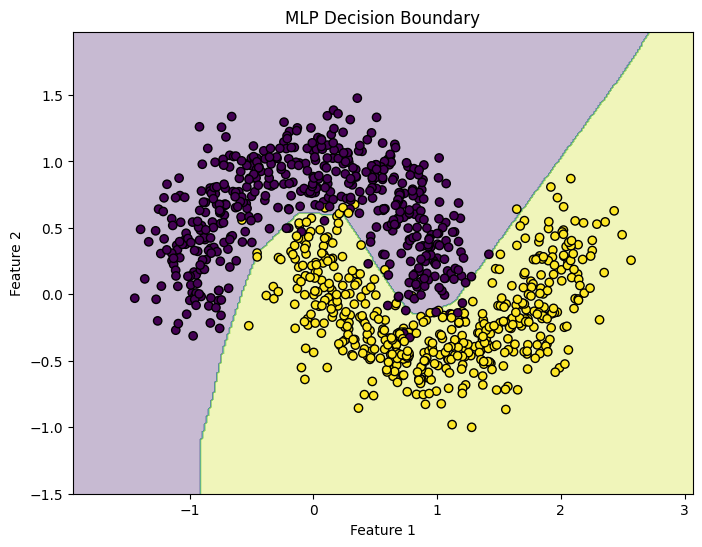

In [21]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = mlp.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    edgecolor="black"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("MLP Decision Boundary")
plt.show()

# 20. Neural Networks with PyTorch

PyTorch provides automatic differentiation and optimized tensor
operations.

Instead of manually deriving and calculating every gradient, we can
define the model and let automatic differentiation calculate the
gradients.

The basic workflow is:

$$
\text{Data}
\rightarrow
\text{Forward Pass}
\rightarrow
\text{Loss}
\rightarrow
\text{Backward Pass}
\rightarrow
\text{Optimizer Step}
$$

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

## PyTorch Model

In [23]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)


model = NeuralNetwork()

print(model)

NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


## Optimizer and Loss

In [24]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Training Loop

In [25]:
X_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_tensor = torch.tensor(
    y_train.reshape(-1, 1),
    dtype=torch.float32
)

epochs = 500

losses = []

for epoch in range(epochs):

    optimizer.zero_grad()

    logits = model(X_tensor)

    loss = criterion(logits, y_tensor)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}: "
            f"Loss = {loss.item():.4f}"
        )

Epoch 0: Loss = 0.7102
Epoch 100: Loss = 0.5429
Epoch 200: Loss = 0.3700
Epoch 300: Loss = 0.2886
Epoch 400: Loss = 0.2533


## Evaluation

In [26]:
X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

with torch.no_grad():

    logits = model(X_test_tensor)

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= 0.5
    ).int().numpy().ravel()

print(
    "Accuracy:",
    accuracy_score(y_test, predictions)
)

Accuracy: 0.95


# 21. Neural Network Implementation Comparison

| Approach | Main Purpose |
|---|---|
| NumPy from scratch | Understand mathematics and algorithms |
| scikit-learn MLP | Classical ML experimentation |
| PyTorch | Modern deep-learning development |

The NumPy implementation is especially important because it exposes
what happens underneath high-level frameworks.

PyTorch then automates much of the mathematical bookkeeping through
automatic differentiation.

# 22. Common Neural Network Problems

## Problem 1: Loss does not decrease

Possible causes:

- learning rate too large
- learning rate too small
- poor initialization
- inappropriate architecture
- incorrect preprocessing

---

## Problem 2: Training accuracy high, validation accuracy low

Likely:

$$
\text{Overfitting}
$$

Possible solutions:

- dropout
- L2 regularization
- early stopping
- more data
- smaller model
- data augmentation

---

## Problem 3: Gradients become extremely small

Possible causes:

- very deep network
- saturating activations
- poor initialization

Possible solutions:

- ReLU-family activations
- better initialization
- normalization
- residual connections

---

## Problem 4: Training is unstable

Check:

- learning rate
- gradient magnitude
- input scaling
- initialization
- numerical stability

# 23. Practical Neural Network Workflow

A reasonable workflow is:

### Step 1 — Understand the data

Determine:

- number of samples
- number of features
- target type
- missing values
- class distribution

### Step 2 — Preprocess

Typical operations:

- imputation
- encoding
- scaling
- train/validation/test split

### Step 3 — Choose architecture

Determine:

- number of layers
- neurons per layer
- activation functions
- output configuration

### Step 4 — Choose loss

Examples:

| Task | Typical Loss |
|---|---|
| Regression | MSE / MAE |
| Binary classification | Binary cross-entropy |
| Multiclass classification | Cross-entropy |

### Step 5 — Choose optimizer

Common choices:

- SGD
- Adam
- AdamW

### Step 6 — Train

Monitor:

- training loss
- validation loss
- relevant evaluation metrics

### Step 7 — Diagnose

Look for:

- underfitting
- overfitting
- unstable optimization
- class imbalance

### Step 8 — Tune

Adjust:

- architecture
- learning rate
- batch size
- regularization
- optimizer
- number of epochs

### Step 9 — Evaluate once

Use the test set only for final evaluation.

# 24. Mathematical Summary

### Neuron

$$
z = \mathbf{w}^T\mathbf{x}+b
$$

$$
a=\sigma(z)
$$

### Layer

$$
\mathbf{z}^{(l)}
=
W^{(l)}\mathbf{a}^{(l-1)}
+
\mathbf{b}^{(l)}
$$

$$
\mathbf{a}^{(l)}
=
f^{(l)}(\mathbf{z}^{(l)})
$$

### Gradient Descent

$$
\theta
\leftarrow
\theta
-
\eta\nabla_\theta L
$$

### Binary Cross-Entropy

$$
L
=
-\frac{1}{n}
\sum_i
[
y_i\log(\hat y_i)
+
(1-y_i)\log(1-\hat y_i)
]
$$

### Softmax

$$
P(y=k|\mathbf{x})
=
\frac{e^{z_k}}
{\sum_j e^{z_j}}
$$

### Backpropagation

Backpropagation uses the chain rule to efficiently calculate:

$$
\frac{\partial L}{\partial W^{(l)}}
$$

and

$$
\frac{\partial L}{\partial b^{(l)}}
$$

for every layer.

# 25. Concept Map
```text
Neural Networks
│
├── Artificial Neuron
│   ├── Weights
│   ├── Bias
│   └── Activation
│
├── Perceptron
│   └── Linear Decision Boundary
│
├── Multilayer Networks
│   ├── Input Layer
│   ├── Hidden Layers
│   └── Output Layer
│
├── Forward Propagation
│   └── Prediction
│
├── Loss Function
│   └── Prediction Error
│
├── Backpropagation
│   └── Gradients
│
├── Optimization
│   ├── Gradient Descent
│   ├── SGD
│   ├── Mini-Batch GD
│   └── Adam
│
├── Activations
│   ├── Sigmoid
│   ├── Tanh
│   ├── ReLU
│   └── Softmax
│
├── Training Problems
│   ├── Overfitting
│   ├── Underfitting
│   ├── Vanishing Gradients
│   └── Exploding Gradients
│
└── Frameworks
    ├── NumPy
    ├── scikit-learn
    └── PyTorch